# Buchdahl Dispersion Model for Model Glass
## Original Workflow Baseline

This notebook establishes the original Buchdahl workflow used by the
first three notebooks in this repository. It implements the **Buchdahl
chromatic coordinate** approach as an alternative to the Chebyshev
intermediate representation.

**Key advantage**: Buchdahl coefficients have direct physical
correspondence with $(n_d, V_d, \Delta P_{g,F})$:

- $n_d$: input directly
- $
u_1$: analytically from $V_d$ (primary dispersion)
- $
u_2$: analytically from $\Delta P_{g,F}$ (secondary dispersion)
- $
u_3, 
u_4$: small residuals, predicted by regression

Original Chebyshev pipeline: 3 inputs $	o$ regression $	o$ **9 coefficients**
(all from regression, max error ~0.03)  
Buchdahl pipeline: 3 inputs $	o$ **2 analytical + 2 regressed** coefficients.

**Forward note**: a later audit in `neural_buchdahl.ipynb` repairs a
small anchor-consistency issue in this original coefficient construction
by re-solving $
u_1, 
u_2$ conditioned on $
u_3, 
u_4$. This notebook
is retained as the original workflow baseline so the development path and
comparisons remain explicit.

## Buchdahl Model

Buchdahl introduces a nonlinear chromatic coordinate:

$$\omega = \frac{\lambda - \lambda_d}{1 + \alpha(\lambda - \lambda_d)}$$

where $\lambda_d = 0.5875618\,\mu m$ (d-line) and $\alpha = 2.5$.

The refractive index is expanded as a power series in $\omega$:

$$n(\lambda) = n_d + \nu_1\omega + \nu_2\omega^2 + \nu_3\omega^3 + \nu_4\omega^4$$

The $\omega$ coordinate compresses the wavelength axis nonlinearly, making the dispersion curve nearly linear in $\omega$. This means fewer terms are needed compared to standard polynomials.

---
# Part 0: Data Loading

**Key feature**: `nd`, `Vd`, `dPgF` are **recomputed from Sellmeier coefficients** using the Schott normal line ($P_{g,F} = 0.6438 - 0.001682\,V_d$), instead of reading stored YAML values.

This ensures all catalogs (Schott, CDGM, Ohara, etc.) share the same baseline — stored `dPgF` values use different normal line coefficients per catalog.

In [1]:
from __future__ import annotations
from pathlib import Path
import yaml
import numpy as np
import copy

In [2]:
import os
import importlib.util

if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    _spec = importlib.util.find_spec("optiland")
    if _spec is None or _spec.origin is None:
        raise RuntimeError(
            "optiland not installed. Run `pip install optiland`, or set the "
            "OPTILAND_DB_ROOT environment variable to the absolute path of the "
            "optiland/database directory."
        )
    DB_ROOT = Path(_spec.origin).parent / "database"

GLASS_ROOT = DB_ROOT / "data-nk" / "glass"

# ── Spectral line wavelengths (um) ──
_LAMBDA_d = 0.5875618   # d-line (yellow He)
_LAMBDA_g = 0.4358343   # g-line (blue Hg)
_LAMBDA_F = 0.4861327   # F-line (blue H)
_LAMBDA_C = 0.6562725   # C-line (red H)


def _sellmeier(lam, B1, C1, B2, C2, B3, C3):
    wl2 = lam ** 2
    return np.sqrt(1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3))


def extract_glass_record(yml_path: Path):
    """
    Extract one glass record.  nd, Vd, dPgF are **recomputed** from
    Sellmeier coefficients using the Schott normal line, so that all
    catalogs share the same baseline.
    """
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)

    data_blocks = doc.get("DATA")
    formula = data_blocks[0]

    if formula.get("type") != "formula 2":
        return None

    coeffs = formula.get("coefficients", []).split()
    if len(coeffs) != 7:
        return None

    wavelength_range = formula.get("wavelength_range", "").strip().split()
    if len(wavelength_range) != 2:
        return None

    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])

    # ── Recompute nd, Vd, dPgF from Sellmeier ──
    nd = _sellmeier(_LAMBDA_d, B1, C1, B2, C2, B3, C3)
    nF = _sellmeier(_LAMBDA_F, B1, C1, B2, C2, B3, C3)
    nC = _sellmeier(_LAMBDA_C, B1, C1, B2, C2, B3, C3)
    ng = _sellmeier(_LAMBDA_g, B1, C1, B2, C2, B3, C3)

    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None

    vd   = (nd - 1.0) / dn_FC
    PgF  = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)   # Schott normal line

    # Keep stored values for reference / auditing
    specs = doc.get("SPECS", {})

    return {
        "name": yml_path.stem,
        "catalog": yml_path.parent.name,
        "wavelength_range": (float(wavelength_range[0]), float(wavelength_range[1])),
        "coeffs": {"B1": B1, "C1": C1, "B2": B2, "C2": C2, "B3": B3, "C3": C3},
        "nd": float(nd),
        "vd": float(vd),
        "dPgF": float(dPgF),
        # stored YAML values (may differ across catalogs)
        "nd_stored": specs.get("nd"),
        "vd_stored": specs.get("Vd"),
        "dPgF_stored": specs.get("dPgF"),
    }


def load_all_glasses(glass_root: Path = GLASS_ROOT):
    glasses = []
    for yml_path in glass_root.rglob("*.yml"):
        try:
            rec = extract_glass_record(yml_path)
            if rec is not None:
                glasses.append(rec)
        except Exception as e:
            print(f"Skipping {yml_path}: {e}")
    return glasses

In [3]:
glasses = load_all_glasses()
print(f"Loaded {len(glasses)} usable glasses")

# ── Audit: compare recomputed vs stored dPgF ──
diffs = []
for g in glasses:
    if g["dPgF_stored"] is not None:
        diffs.append((g["name"], g["catalog"],
                       g["dPgF"] - g["dPgF_stored"],
                       g["dPgF"], g["dPgF_stored"]))

diffs_sorted = sorted(diffs, key=lambda x: abs(x[2]), reverse=True)
print("\nTop 10 |dPgF_recomputed - dPgF_stored| discrepancies:")
print(f"  {'Name':<20} {'Catalog':<10} {'Recomputed':>10} {'Stored':>10} {'Diff':>12}")
for name, cat, diff, recomp, stored in diffs_sorted[:10]:
    print(f"  {name:<20} {cat:<10} {recomp:>10.4f} {stored:>10.4f} {diff:>+12.4e}")

# ── Filter by wavelength range ──
mask = [g["wavelength_range"][0] <= 0.36501 and g["wavelength_range"][1] >= 2.3
        for g in glasses]
glasses_filtered = [g for g, m in zip(glasses, mask) if m]
print(f"\nAfter wavelength filtering (0.365-2.3 um): {len(glasses_filtered)} glasses")

# ── Sanity: remove glasses where stored dPgF was grossly wrong ──
# (indicates bad data in the YAML, e.g. L-BAL43 dPgF=0.5415)
before = len(glasses_filtered)
glasses_filtered = [g for g in glasses_filtered
                    if g["dPgF_stored"] is None
                    or abs(g["dPgF"] - g["dPgF_stored"]) < 0.05]
print(f"After dPgF sanity filter (|diff| < 0.05): {len(glasses_filtered)} glasses "
      f"(removed {before - len(glasses_filtered)})")

Loaded 649 usable glasses

Top 10 |dPgF_recomputed - dPgF_stored| discrepancies:
  Name                 Catalog    Recomputed     Stored         Diff
  L-BAL43              ohara         -0.0018     0.5415  -5.4333e-01
  SF6G05               schott         0.0108     0.1080  -9.7230e-02
  S-FPL53              ohara          0.0502     0.0461  +4.1044e-03
  S-FPL55              ohara          0.0494     0.0457  +3.7193e-03
  S-FPL52              ohara          0.0422     0.0386  +3.5936e-03
  S-FPL51Y             ohara          0.0308     0.0279  +2.8739e-03
  S-FPL51              ohara          0.0308     0.0280  +2.8197e-03
  S-FPM3               ohara          0.0212     0.0186  +2.5877e-03
  S-FSL5               ohara          0.0044     0.0022  +2.1887e-03
  S-FSL5Y              ohara          0.0042     0.0021  +2.0746e-03

After wavelength filtering (0.365-2.3 um): 544 glasses
After dPgF sanity filter (|diff| < 0.05): 543 glasses (removed 1)


### Plot 1 — Catalog footprint in $(V_d, n_d)$ and $(V_d, \Delta P_{g,F})$

Shows where the 543 surviving glasses live and the **convex hull** of the training set. Any tolerancing perturbation that pushes $(n_d, V_d, \Delta P_{g,F})$ outside this hull will be *extrapolated* by the $\nu_3,\nu_4$ regression downstream.

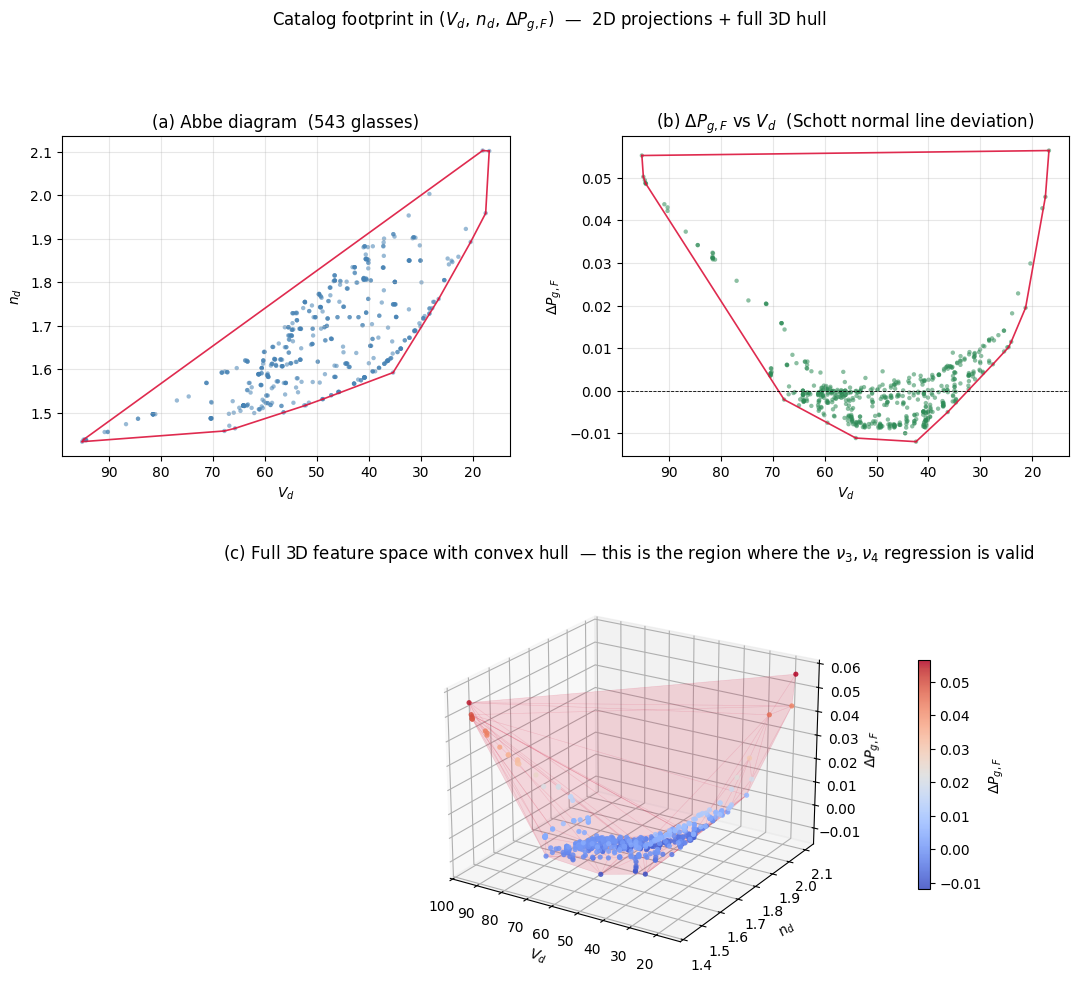

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

_nd   = np.array([g["nd"]   for g in glasses_filtered])
_vd   = np.array([g["vd"]   for g in glasses_filtered])
_dPgF = np.array([g["dPgF"] for g in glasses_filtered])

fig = plt.figure(figsize=(13, 11))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1.3], hspace=0.3, wspace=0.25)

# ─────────────────────────── (a) Abbe diagram ──────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.scatter(_vd, _nd, s=10, alpha=0.55, color="steelblue", edgecolors="none")
pts = np.column_stack([_vd, _nd])
hull = ConvexHull(pts)
for simp in hull.simplices:
    ax.plot(pts[simp, 0], pts[simp, 1], color="crimson", lw=1.2, alpha=0.9)
ax.invert_xaxis()
ax.set_xlabel(r"$V_d$")
ax.set_ylabel(r"$n_d$")
ax.set_title(f"(a) Abbe diagram  ({len(glasses_filtered)} glasses)")
ax.grid(alpha=0.3)

# ─────────────────────────── (b) V_d vs ΔP_gF ──────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.scatter(_vd, _dPgF, s=10, alpha=0.55, color="seagreen", edgecolors="none")
pts2 = np.column_stack([_vd, _dPgF])
hull2 = ConvexHull(pts2)
for simp in hull2.simplices:
    ax.plot(pts2[simp, 0], pts2[simp, 1], color="crimson", lw=1.2, alpha=0.9)
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.invert_xaxis()
ax.set_xlabel(r"$V_d$")
ax.set_ylabel(r"$\Delta P_{g,F}$")
ax.set_title(r"(b) $\Delta P_{g,F}$ vs $V_d$  (Schott normal line deviation)")
ax.grid(alpha=0.3)

# ────────────── (c) 3D scatter + 3D convex hull (what regression sees) ──
ax3 = fig.add_subplot(gs[1, :], projection="3d")
pts3 = np.column_stack([_vd, _nd, _dPgF])
hull3 = ConvexHull(pts3)

# Hull as translucent triangle mesh
faces = [pts3[simp] for simp in hull3.simplices]
mesh = Poly3DCollection(faces, alpha=0.08, facecolor="crimson",
                        edgecolor="crimson", linewidths=0.4)
ax3.add_collection3d(mesh)

# Points, colored by dPgF for extra visual cue
sc = ax3.scatter(_vd, _nd, _dPgF, c=_dPgF, cmap="coolwarm", s=14,  # type: ignore[arg-type]
                 alpha=0.85, edgecolors="none")
cb = fig.colorbar(sc, ax=ax3, shrink=0.55, pad=0.08)
cb.set_label(r"$\Delta P_{g,F}$")

ax3.set_xlabel(r"$V_d$")
ax3.set_ylabel(r"$n_d$")
ax3.set_zlabel(r"$\Delta P_{g,F}$")
ax3.invert_xaxis()
ax3.set_title(
    "(c) Full 3D feature space with convex hull  "
    "— this is the region where the $\\nu_3,\\nu_4$ regression is valid"
)
ax3.view_init(elev=22, azim=-58)

plt.suptitle(
    r"Catalog footprint in $(V_d,\,n_d,\,\Delta P_{g,F})$  —  2D projections + full 3D hull",
    y=0.995, fontsize=12,
)
plt.show()


In [5]:
# Same 17 wavelengths as original notebook
wavelengths = np.array([
    0.36501, 0.40466, 0.43583, 0.48613, 0.54607,
    0.58756, 0.58929, 0.6328,  0.64385, 0.65627,
    0.70652, 0.85211, 1.01398, 1.060,   1.52958,
    1.97009, 2.3
])


def sellmeier(wavelength, B1, C1, B2, C2, B3, C3):
    wl2 = wavelength ** 2
    n2 = 1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3)
    return np.sqrt(n2)


def get_indices(glass, wavelengths):
    c = glass["coeffs"]
    return sellmeier(wavelengths, c["B1"], c["C1"], c["B2"], c["C2"], c["B3"], c["C3"])

---
# Part 1: Buchdahl Core Functions

In [6]:
# ── Buchdahl constants ──
LAMBDA_D = 0.5875618   # d-line (um)
LAMBDA_g = 0.4358343   # g-line (um)
LAMBDA_F = 0.4861327   # F-line (um)
LAMBDA_C = 0.6562725   # C-line (um)
ALPHA    = 2.5         # Buchdahl dispersion constant


def buchdahl_omega(lam, lam_d=LAMBDA_D, alpha=ALPHA):
    """Compute Buchdahl chromatic coordinate omega."""
    dl = lam - lam_d
    return dl / (1.0 + alpha * dl)


def buchdahl_eval(nd, nu_coeffs, omega):
    """
    Evaluate n(lambda) = nd + nu1*w + nu2*w^2 + nu3*w^3 + ...
    nu_coeffs = [nu1, nu2, ...]
    """
    n = np.full_like(omega, nd, dtype=np.float64)
    for k, nu_k in enumerate(nu_coeffs, start=1):
        n += nu_k * omega**k
    return n


def buchdahl_fit_from_indices(nd, indices, omega, order=4):
    """
    Fit [nu1, nu2, ..., nu_order] by least squares.
    Design matrix: columns = [w, w^2, w^3, ..., w^order]
    Target: n(lambda) - nd
    """
    A = np.column_stack([omega**k for k in range(1, order + 1)])
    b = indices - nd
    nu, residuals, rank, sv = np.linalg.lstsq(A, b, rcond=None)
    return nu


# Precompute reference omega values for spectral lines
OMEGA_g = buchdahl_omega(LAMBDA_g)
OMEGA_F = buchdahl_omega(LAMBDA_F)
OMEGA_C = buchdahl_omega(LAMBDA_C)

print(f"omega_g = {OMEGA_g:.6f}")
print(f"omega_F = {OMEGA_F:.6f}")
print(f"omega_C = {OMEGA_C:.6f}")
print(f"omega range for 0.365-2.3 um: [{buchdahl_omega(0.365):.4f}, {buchdahl_omega(2.3):.4f}]")

omega_g = -0.244453
omega_F = -0.135886
omega_C = 0.058638
omega range for 0.365-2.3 um: [-0.5017, 0.3243]


---
# Part 2: Buchdahl Fit Quality

For each glass, fit Buchdahl coefficients from the Sellmeier truth values, and compare fit quality at different orders.

This is analogous to the original notebook's Chebyshev fit step.

In [7]:
omega_17 = buchdahl_omega(wavelengths)

# Fit at different orders and record max errors
for order in [2, 3, 4, 5]:
    max_errors = []
    for g in glasses_filtered:
        nd = g["nd"]
        indices_true = get_indices(g, wavelengths)
        nu = buchdahl_fit_from_indices(nd, indices_true, omega_17, order=order)
        indices_fit = buchdahl_eval(nd, nu, omega_17)
        max_errors.append(np.max(np.abs(indices_true - indices_fit)))
    print(f"Buchdahl order {order}: max fit error = {max(max_errors):.2e}, "
          f"mean = {np.mean(max_errors):.2e}")

# Compare with Chebyshev 8th order
norm_wths = 2 * (wavelengths - wavelengths.min()) / (wavelengths.max() - wavelengths.min()) - 1
cheby_max_errors = []
for g in glasses_filtered:
    indices_true = get_indices(g, wavelengths)
    coeffs = np.polynomial.chebyshev.chebfit(norm_wths, indices_true, 8)
    indices_fit = np.polynomial.chebyshev.chebval(norm_wths, coeffs)
    cheby_max_errors.append(np.max(np.abs(indices_true - indices_fit)))
print(f"\nChebyshev degree 8:  max fit error = {max(cheby_max_errors):.2e}, "
      f"mean = {np.mean(cheby_max_errors):.2e}")

Buchdahl order 2: max fit error = 8.42e-03, mean = 5.53e-03
Buchdahl order 3: max fit error = 5.65e-03, mean = 4.05e-03
Buchdahl order 4: max fit error = 2.99e-03, mean = 2.10e-03
Buchdahl order 5: max fit error = 2.03e-03, mean = 1.43e-03

Chebyshev degree 8:  max fit error = 2.53e-03, mean = 1.19e-04


### Plot 2 — Buchdahl fit residual vs wavelength for representative glasses

For four representative glasses (high $V_d$ crown, low $V_d$ flint, anomalous $\Delta P_{g,F}$, median $V_d$), plot $n_{fit}(\lambda)-n_{true}(\lambda)$ at orders 2/3/4. This exposes whether fit error is spread across the band or concentrated at the UV/NIR ends — the latter would bias tolerancing results at the extreme wavelengths.

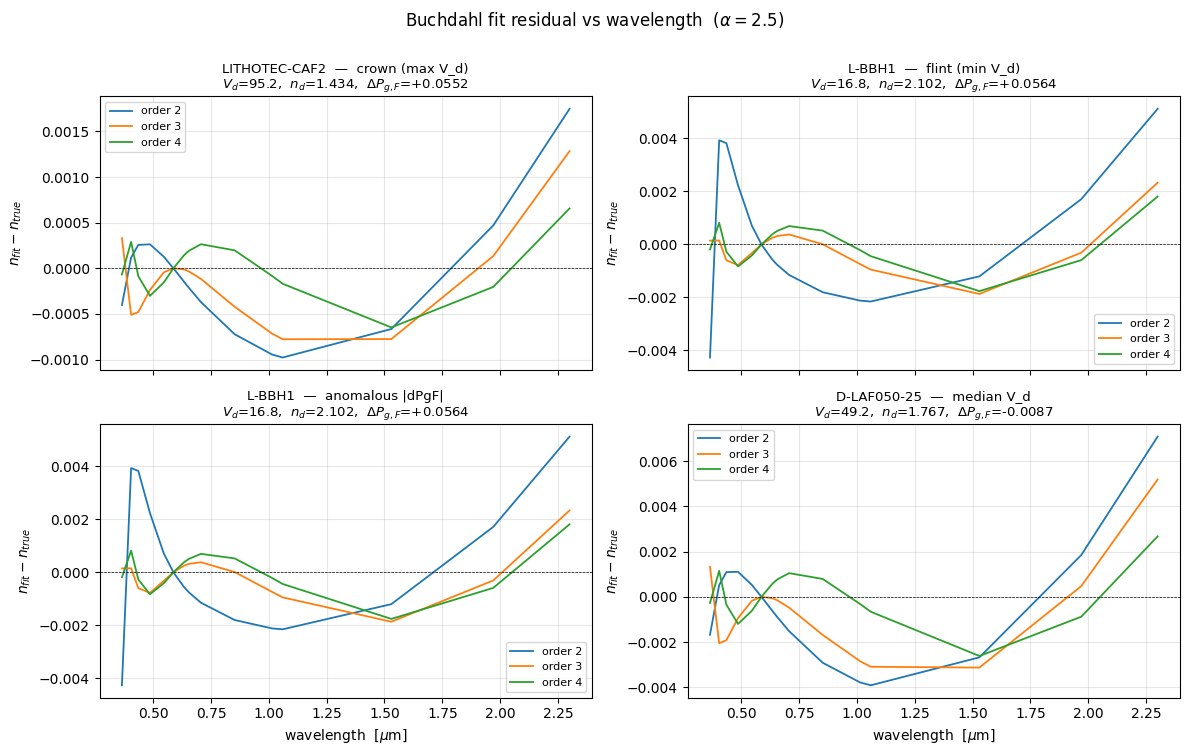

In [8]:
import matplotlib.pyplot as plt

_vd_arr   = np.array([g["vd"]   for g in glasses_filtered])
_dPgF_arr = np.array([g["dPgF"] for g in glasses_filtered])

idx_crown  = int(np.argmax(_vd_arr))
idx_flint  = int(np.argmin(_vd_arr))
idx_anom   = int(np.argmax(np.abs(_dPgF_arr)))
idx_median = int(np.argsort(_vd_arr)[len(_vd_arr) // 2])

reps = [
    ("crown (max V_d)",      idx_crown),
    ("flint (min V_d)",      idx_flint),
    ("anomalous |dPgF|",     idx_anom),
    ("median V_d",           idx_median),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
orders = [2, 3, 4]
colors = {2: "tab:blue", 3: "tab:orange", 4: "tab:green"}

for ax, (label, i) in zip(axes.flat, reps):
    g = glasses_filtered[i]
    indices_true = get_indices(g, wavelengths)
    for order in orders:
        nu = buchdahl_fit_from_indices(g["nd"], indices_true, omega_17, order=order)
        indices_fit = buchdahl_eval(g["nd"], nu, omega_17)
        ax.plot(wavelengths, indices_fit - indices_true,
                lw=1.3, color=colors[order], label=f"order {order}")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_title(
        f"{g['name']}  —  {label}\n"
        f"$V_d$={g['vd']:.1f},  $n_d$={g['nd']:.3f},  "
        f"$\\Delta P_{{g,F}}$={g['dPgF']:+.4f}",
        fontsize=9.5,
    )
    ax.set_ylabel(r"$n_{fit}-n_{true}$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

for ax in axes[1]:
    ax.set_xlabel(r"wavelength  [$\mu$m]")

plt.suptitle(r"Buchdahl fit residual vs wavelength  ($\alpha=2.5$)", y=1.00)
plt.tight_layout()
plt.show()


---
# Part 2b: Optimize α

The standard Buchdahl constant $\alpha = 2.5$ was designed for the visible range. For the full 0.365–2.3 μm range, $\omega$ spans $[-0.50, +0.32]$ — asymmetric and large, causing poor series convergence.

We search for the $\alpha$ that minimizes the **maximum Buchdahl fit error across all 533 glasses** at each order.

In [9]:
def buchdahl_omega_alpha(lam, alpha, lam_d=LAMBDA_D):
    """Omega with variable alpha."""
    dl = lam - lam_d
    return dl / (1.0 + alpha * dl)


def eval_alpha(alpha, glasses, wavelengths, order=4):
    """
    For a given alpha, fit Buchdahl at specified order for all glasses,
    return (max_error_across_glasses, mean_error_across_glasses).
    """
    omega = buchdahl_omega_alpha(wavelengths, alpha)
    max_errors = []
    for g in glasses:
        nd = g["nd"]
        indices_true = get_indices(g, wavelengths)
        # Fit
        A = np.column_stack([omega**k for k in range(1, order + 1)])
        b = indices_true - nd
        nu, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        # Evaluate
        indices_fit = nd + A @ nu
        max_errors.append(np.max(np.abs(indices_true - indices_fit)))
    return np.max(max_errors), np.mean(max_errors)


# ── Grid search over alpha for each order ──
alphas = np.linspace(0.3, 6.0, 200)

print(f"{'Order':<8} {'Best alpha':>10} {'Max err (opt)':>14} {'Max err (2.5)':>14} {'Improvement':>12}")
print("-" * 62)

best_alphas = {}
for order in [2, 3, 4, 5]:
    results = []
    for a in alphas:
        max_err, mean_err = eval_alpha(a, glasses_filtered, wavelengths, order)
        results.append((a, max_err, mean_err))
    results = np.array(results)

    # Best alpha by minimum of max error
    idx_best = np.argmin(results[:, 1])
    a_best = results[idx_best, 0]
    err_best = results[idx_best, 1]

    # Compare with alpha=2.5
    err_25, _ = eval_alpha(2.5, glasses_filtered, wavelengths, order)

    best_alphas[order] = a_best
    print(f"{order:<8} {a_best:>10.3f} {err_best:>14.2e} {err_25:>14.2e} {err_25/err_best:>11.1f}x")

print(f"\nBest alpha for order 4: {best_alphas[4]:.3f}")

Order    Best alpha  Max err (opt)  Max err (2.5)  Improvement
--------------------------------------------------------------
2             2.591       8.19e-03       8.42e-03         1.0x
3             1.933       3.58e-03       5.65e-03         1.6x
4             1.818       2.39e-03       2.99e-03         1.2x
5             1.560       6.53e-04       2.03e-03         3.1x

Best alpha for order 4: 1.818


In [10]:
# ── Check convergence with optimal alpha vs 2.5 for D-FK61-25 ──
g1 = glasses_filtered[0]
indices_true = get_indices(g1, wavelengths)
ALPHA_OPT = best_alphas[4]

print(f"Glass: {g1['name']}")
print(f"Comparing alpha=2.5 vs alpha={ALPHA_OPT:.3f}\n")

for a_val, a_name in [(2.5, "alpha=2.5"), (ALPHA_OPT, f"alpha={ALPHA_OPT:.3f}")]:
    omega_a = buchdahl_omega_alpha(wavelengths, a_val)
    print(f"--- {a_name} ---")
    print(f"  omega range: [{omega_a.min():.4f}, {omega_a.max():.4f}]")
    for order in [2, 3, 4]:
        A_mat = np.column_stack([omega_a**k for k in range(1, order + 1)])
        nu, _, _, _ = np.linalg.lstsq(A_mat, indices_true - g1["nd"], rcond=None)
        err = np.max(np.abs(indices_true - g1["nd"] - A_mat @ nu))
        nu_str = ", ".join([f"nu{k+1}={v:.4e}" for k, v in enumerate(nu)])
        print(f"  order {order}: max_err={err:.2e}  {nu_str}")
    print()

Glass: D-FK61-25
Comparing alpha=2.5 vs alpha=1.818

--- alpha=2.5 ---
  omega range: [-0.5017, 0.3243]
  order 2: max_err=2.81e-03  nu1=-3.6813e-02, nu2=-1.7336e-02
  order 3: max_err=2.05e-03  nu1=-3.1023e-02, nu2=-2.6173e-02, nu3=-5.0179e-02
  order 4: max_err=1.05e-03  nu1=-2.5895e-02, nu2=-7.1366e-04, nu3=-1.3142e-01, nu4=-2.3250e-01

--- alpha=1.818 ---
  omega range: [-0.3738, 0.4163]
  order 2: max_err=2.45e-03  nu1=-3.5692e-02, nu2=4.2523e-03
  order 3: max_err=1.17e-03  nu1=-2.7672e-02, nu2=8.3784e-03, nu3=-7.3876e-02
  order 4: max_err=6.59e-04  nu1=-2.9541e-02, nu2=2.9506e-02, nu3=-5.2349e-02, nu4=-1.6618e-01



### Plot 3 — $\alpha$ optimization curve

Max fit error (over all 543 glasses) vs the Buchdahl dispersion constant $\alpha$, for orders 2–5. Marks the default $\alpha=2.5$ and the optimum $\alpha_\text{opt}$. A coarser grid (80 pts) is used here for plotting speed.

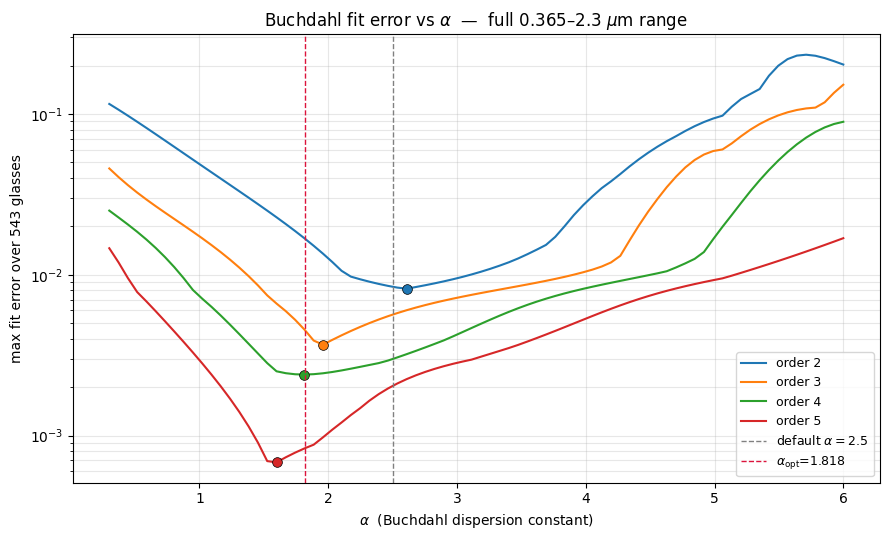

In [11]:
import matplotlib.pyplot as plt

_alphas_plot = np.linspace(0.3, 6.0, 80)
_curves = {}
for order in [2, 3, 4, 5]:
    maxes = np.empty_like(_alphas_plot)
    for i, a in enumerate(_alphas_plot):
        m, _ = eval_alpha(a, glasses_filtered, wavelengths, order)
        maxes[i] = m
    _curves[order] = maxes

fig, ax = plt.subplots(figsize=(9, 5.5))
for order, maxes in _curves.items():
    line, = ax.plot(_alphas_plot, maxes, lw=1.5, label=f"order {order}")
    i_best = int(np.argmin(maxes))
    ax.plot(_alphas_plot[i_best], maxes[i_best], "o", ms=7,
            color=line.get_color(), mec="k", mew=0.5)

ax.axvline(2.5, color="gray", ls="--", lw=1, label=r"default $\alpha=2.5$")
ax.axvline(ALPHA_OPT, color="crimson", ls="--", lw=1,
           label=fr"$\alpha_\mathrm{{opt}}$={ALPHA_OPT:.3f}")
ax.set_yscale("log")
ax.set_xlabel(r"$\alpha$  (Buchdahl dispersion constant)")
ax.set_ylabel(r"max fit error over 543 glasses")
ax.set_title(r"Buchdahl fit error vs $\alpha$  —  full 0.365–2.3 $\mu$m range")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
# Part 3: Analytical $\nu_1$, $\nu_2$ from $(n_d, V_d, \Delta P_{g,F})$

From the Buchdahl expansion:

$$n_F - n_C = \nu_1(\omega_F - \omega_C) + \nu_2(\omega_F^2 - \omega_C^2) + \cdots$$

$$n_g - n_F = \nu_1(\omega_g - \omega_F) + \nu_2(\omega_g^2 - \omega_F^2) + \cdots$$

Truncating at 2nd order, this gives a $2 \times 2$ linear system:

$$\begin{bmatrix} \omega_F - \omega_C & \omega_F^2 - \omega_C^2 \\ \omega_g - \omega_F & \omega_g^2 - \omega_F^2 \end{bmatrix} \begin{bmatrix} \nu_1 \\ \nu_2 \end{bmatrix} = \begin{bmatrix} \Delta n_{FC} \\ \Delta n_{gF} \end{bmatrix}$$

where:
- $\Delta n_{FC} = (n_d - 1) / V_d$
- $\Delta n_{gF} = P_{g,F} \times \Delta n_{FC}$
- $P_{g,F} = 0.6438 - 0.001682 V_d + \Delta P_{g,F}$

In [12]:
def analytical_nu12(nd, vd, dPgF):
    """
    Solve nu1, nu2 analytically from (nd, Vd, dPgF).
    Uses 2x2 linear system from Buchdahl expansion truncated at order 2.
    """
    dn_FC = (nd - 1.0) / vd               # n_F - n_C
    PgF   = 0.6438 - 0.001682 * vd + dPgF # partial dispersion
    dn_gF = PgF * dn_FC                    # n_g - n_F

    # 2x2 system coefficients
    M = np.array([
        [OMEGA_F - OMEGA_C,   OMEGA_F**2 - OMEGA_C**2],
        [OMEGA_g - OMEGA_F,   OMEGA_g**2 - OMEGA_F**2],
    ])
    rhs = np.array([dn_FC, dn_gF])
    nu12 = np.linalg.solve(M, rhs)
    return nu12   # [nu1, nu2]


# ── Verify: compare analytical vs full-fit nu1, nu2 for all glasses ──
nu1_analytical = []
nu1_fitted = []
nu2_analytical = []
nu2_fitted = []

for g in glasses_filtered:
    # Analytical
    nu12_a = analytical_nu12(g["nd"], g["vd"], g["dPgF"])
    nu1_analytical.append(nu12_a[0])
    nu2_analytical.append(nu12_a[1])

    # Full 4th-order fit from Sellmeier truth
    indices = get_indices(g, wavelengths)
    nu_full = buchdahl_fit_from_indices(g["nd"], indices, omega_17, order=4)
    nu1_fitted.append(nu_full[0])
    nu2_fitted.append(nu_full[1])

nu1_analytical = np.array(nu1_analytical)
nu1_fitted     = np.array(nu1_fitted)
nu2_analytical = np.array(nu2_analytical)
nu2_fitted     = np.array(nu2_fitted)

print("=== Analytical vs Full-Fit Comparison ===")
print(f"nu1: max |diff| = {np.max(np.abs(nu1_analytical - nu1_fitted)):.4e}, "
      f"mean |diff| = {np.mean(np.abs(nu1_analytical - nu1_fitted)):.4e}")
print(f"nu2: max |diff| = {np.max(np.abs(nu2_analytical - nu2_fitted)):.4e}, "
      f"mean |diff| = {np.mean(np.abs(nu2_analytical - nu2_fitted)):.4e}")
print(f"\nnu1 range: [{nu1_fitted.min():.4f}, {nu1_fitted.max():.4f}]")
print(f"nu2 range: [{nu2_fitted.min():.4f}, {nu2_fitted.max():.4f}]")

=== Analytical vs Full-Fit Comparison ===
nu1: max |diff| = 1.5257e-02, mean |diff| = 1.1234e-02
nu2: max |diff| = 2.1689e-02, mean |diff| = 6.3855e-03

nu1 range: [-0.3118, -0.0190]
nu2 range: [-0.0049, 0.2054]


---
# Part 4: Regression for $\nu_3$, $\nu_4$

With $\nu_1, \nu_2$ determined analytically, compute the residual:

$$r(\lambda) = n_{\text{Sellmeier}}(\lambda) - n_d - \nu_1\omega - \nu_2\omega^2$$

Then fit $\nu_3, \nu_4$ from $r(\lambda) \approx \nu_3\omega^3 + \nu_4\omega^4$.

Finally, regress $(n_d, V_d, \Delta P_{g,F}) \to (\nu_3, \nu_4)$ using least squares.

In [13]:
# ── Step 1: For each glass, compute analytical nu1,nu2 then fit nu3,nu4 from residual ──

glasses_buchdahl = copy.deepcopy(glasses_filtered)

for g in glasses_buchdahl:
    nd, vd, dPgF = g["nd"], g["vd"], g["dPgF"]
    indices_true = get_indices(g, wavelengths)

    # Analytical nu1, nu2
    nu12 = analytical_nu12(nd, vd, dPgF)

    # Residual after subtracting analytical model
    residual = indices_true - nd - nu12[0]*omega_17 - nu12[1]*omega_17**2

    # Fit nu3, nu4 from residual
    A_res = np.column_stack([omega_17**3, omega_17**4])
    nu34, _, _, _ = np.linalg.lstsq(A_res, residual, rcond=None)

    # Full reconstructed model
    nu_all = np.array([nu12[0], nu12[1], nu34[0], nu34[1]])
    indices_buch = buchdahl_eval(nd, nu_all, omega_17)

    g["nu12_analytical"] = nu12
    g["nu34_residual"]   = nu34
    g["nu_all"]          = nu_all
    g["buchdahl_fit_error"] = np.max(np.abs(indices_true - indices_buch))

buch_fit_errors = [g["buchdahl_fit_error"] for g in glasses_buchdahl]
print("Buchdahl (analytical nu12 + fitted nu34):")
print(f"  Max fit error: {max(buch_fit_errors):.2e}")
print(f"  Mean fit error: {np.mean(buch_fit_errors):.2e}")

# Also check order-2 only (nu3=nu4=0)
trunc_errors = []
for g in glasses_buchdahl:
    nd = g["nd"]
    nu12 = g["nu12_analytical"]
    indices_true = get_indices(g, wavelengths)
    indices_trunc = buchdahl_eval(nd, nu12, omega_17)
    trunc_errors.append(np.max(np.abs(indices_true - indices_trunc)))

print("\nBuchdahl (analytical nu12 only, nu3=nu4=0):")
print(f"  Max fit error: {max(trunc_errors):.2e}")
print(f"  Mean fit error: {np.mean(trunc_errors):.2e}")

Buchdahl (analytical nu12 + fitted nu34):
  Max fit error: 4.28e-03
  Mean fit error: 3.09e-03

Buchdahl (analytical nu12 only, nu3=nu4=0):
  Max fit error: 1.83e-02
  Mean fit error: 1.15e-02


In [14]:
# ── Step 2: Regress nu3, nu4 from (nd, vd, dPgF) ──

def feature_vec(nd, vd, dPgF):
    """Same 20-dim feature as original notebook for fair comparison."""
    square = np.array([
        1.0, nd, vd, dPgF,
        nd**2, vd**2, dPgF**2,
        nd*vd, nd*dPgF, vd*dPgF
    ], dtype=np.float64)
    cube = np.array([
        nd**3, vd**3, dPgF**3,
        nd**2*vd, nd**2*dPgF,
        vd**2*nd, vd**2*dPgF,
        dPgF**2*nd, dPgF**2*vd,
        nd*vd*dPgF
    ], dtype=np.float64)
    return np.concatenate([square, cube])


# Build feature and target matrices
Phi = np.vstack([feature_vec(g["nd"], g["vd"], g["dPgF"]) for g in glasses_buchdahl])
Y_nu34 = np.vstack([g["nu34_residual"] for g in glasses_buchdahl])

print(f"Feature matrix Phi: {Phi.shape}")    # (N, 20)
print(f"Target matrix Y:    {Y_nu34.shape}")  # (N, 2)

# Least squares regression
result = np.linalg.lstsq(Phi, Y_nu34, rcond=None)
A_buch = result[0]
print(f"\nRegression matrix A: {A_buch.shape}")  # (20, 2)
print(f"Residuals (sum of squared): {result[1]}")

Feature matrix Phi: (543, 20)
Target matrix Y:    (543, 2)

Regression matrix A: (20, 2)
Residuals (sum of squared): [0.09365546 0.37599766]


In [15]:
# ── Check regression quality on training data ──

Y_nu34_pred = Phi @ A_buch
reg_errors = np.abs(Y_nu34 - Y_nu34_pred)

print("Regression quality (nu3, nu4 prediction):")
print(f"  nu3: max err = {reg_errors[:, 0].max():.2e}, mean = {reg_errors[:, 0].mean():.2e}")
print(f"  nu4: max err = {reg_errors[:, 1].max():.2e}, mean = {reg_errors[:, 1].mean():.2e}")
print(f"\n  nu3 true range: [{Y_nu34[:, 0].min():.4e}, {Y_nu34[:, 0].max():.4e}]")
print(f"  nu4 true range: [{Y_nu34[:, 1].min():.4e}, {Y_nu34[:, 1].max():.4e}]")

Regression quality (nu3, nu4 prediction):
  nu3: max err = 5.98e-02, mean = 9.32e-03
  nu4: max err = 1.18e-01, mean = 1.87e-02

  nu3 true range: [-2.6719e-01, -4.1227e-02]
  nu4 true range: [-4.8034e-01, -7.9590e-02]


### Plot 5 — $\nu_3,\nu_4$ regression residuals in $(V_d, n_d)$ space

Signed residuals $\nu_{3,4}^\text{true}-\nu_{3,4}^\text{pred}$ per glass, placed on the Abbe diagram. Systematic colour structure (clustered +/-) means the 20-dim feature vector is missing something — external extrapolation during tolerancing will be worse in regions where residuals are large and/or one-sided.

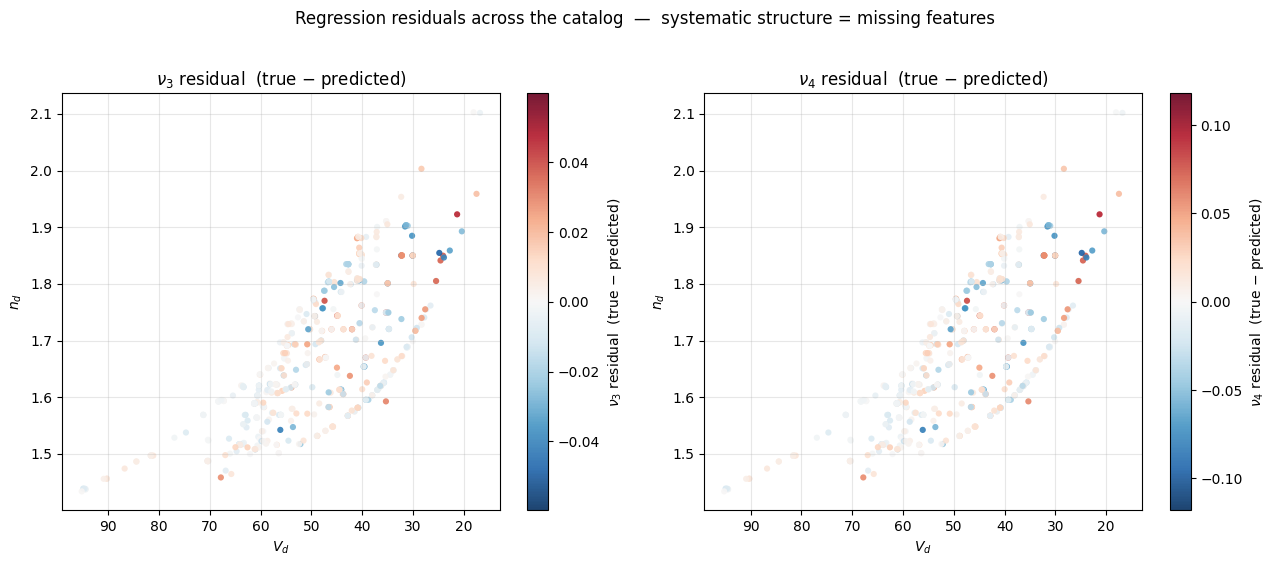

In [16]:
import matplotlib.pyplot as plt

_vd_b = np.array([g["vd"] for g in glasses_buchdahl])
_nd_b = np.array([g["nd"] for g in glasses_buchdahl])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
labels = [r"$\nu_3$ residual  (true − predicted)",
          r"$\nu_4$ residual  (true − predicted)"]

for ax, k, lab in zip(axes, [0, 1], labels):
    res_k = Y_nu34[:, k] - Y_nu34_pred[:, k]
    vmax = float(np.max(np.abs(res_k)))
    sc = ax.scatter(_vd_b, _nd_b, c=res_k, s=20, cmap="RdBu_r",
                    vmin=-vmax, vmax=+vmax, alpha=0.9, edgecolors="none")
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label(lab)
    ax.set_xlabel(r"$V_d$")
    ax.set_ylabel(r"$n_d$")
    ax.invert_xaxis()
    ax.set_title(lab)
    ax.grid(alpha=0.3)

plt.suptitle(
    r"Regression residuals across the catalog  —  systematic structure = missing features",
    y=1.02,
)
plt.tight_layout()
plt.show()


### Full pipeline with optimized α

Re-run the complete pipeline (analytical $\nu_1, \nu_2$ + regressed $\nu_3, \nu_4$) using the optimized $\alpha$, and compare end-to-end error with $\alpha=2.5$.

In [17]:
# ── Full pipeline with optimized alpha ──

ALPHA_OPT = best_alphas[4]

# Recompute spectral line omegas with new alpha
OMEGA_g_opt = buchdahl_omega_alpha(LAMBDA_g, ALPHA_OPT)
OMEGA_F_opt = buchdahl_omega_alpha(LAMBDA_F, ALPHA_OPT)
OMEGA_C_opt = buchdahl_omega_alpha(LAMBDA_C, ALPHA_OPT)
omega_17_opt = buchdahl_omega_alpha(wavelengths, ALPHA_OPT)

print(f"Optimized alpha = {ALPHA_OPT:.3f}")
print(f"omega range: [{omega_17_opt.min():.4f}, {omega_17_opt.max():.4f}]")
print(f"(was [{omega_17.min():.4f}, {omega_17.max():.4f}] with alpha=2.5)\n")


def analytical_nu12_opt(nd, vd, dPgF):
    """Analytical nu1, nu2 with optimized alpha."""
    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC

    M = np.array([
        [OMEGA_F_opt - OMEGA_C_opt, OMEGA_F_opt**2 - OMEGA_C_opt**2],
        [OMEGA_g_opt - OMEGA_F_opt, OMEGA_g_opt**2 - OMEGA_F_opt**2],
    ])
    rhs = np.array([dn_FC, dn_gF])
    return np.linalg.solve(M, rhs)


# ── Step 1: Fit nu3, nu4 from residuals (with optimized alpha) ──
glasses_buch_opt = copy.deepcopy(glasses_filtered)

for g in glasses_buch_opt:
    nd, vd, dPgF = g["nd"], g["vd"], g["dPgF"]
    indices_true = get_indices(g, wavelengths)

    nu12 = analytical_nu12_opt(nd, vd, dPgF)
    residual = indices_true - nd - nu12[0]*omega_17_opt - nu12[1]*omega_17_opt**2

    A_res = np.column_stack([omega_17_opt**3, omega_17_opt**4])
    nu34, _, _, _ = np.linalg.lstsq(A_res, residual, rcond=None)

    g["nu12"] = nu12
    g["nu34"] = nu34

# ── Step 2: Regress nu3, nu4 ──
Phi_opt = np.vstack([feature_vec(g["nd"], g["vd"], g["dPgF"]) for g in glasses_buch_opt])
Y_nu34_opt = np.vstack([g["nu34"] for g in glasses_buch_opt])

A_buch_opt = np.linalg.lstsq(Phi_opt, Y_nu34_opt, rcond=None)[0]

# ── Step 3: End-to-end test on shifted wavelengths ──
wth_shift = wavelengths + 0.01
omega_shift_opt = buchdahl_omega_alpha(wth_shift, ALPHA_OPT)

# Also rebuild alpha=2.5 Chebyshev for reference
norm_wths_train = 2 * (wavelengths - wavelengths.min()) / (wavelengths.max() - wavelengths.min()) - 1
norm_wths_shift = 2 * (wth_shift - wavelengths.min()) / (wavelengths.max() - wavelengths.min()) - 1
Phi_c = np.vstack([feature_vec(g["nd"], g["vd"], g["dPgF"]) for g in glasses_filtered])
Y_c = []
for g in glasses_filtered:
    idx = get_indices(g, wavelengths)
    c = np.polynomial.chebyshev.chebfit(norm_wths_train, idx, 8)
    Y_c.append(c)
Y_c = np.vstack(Y_c)
A_c = np.linalg.lstsq(Phi_c, Y_c, rcond=None)[0]

errs_cheby = []
errs_buch25 = []
errs_buch_opt = []

omega_shift_25 = buchdahl_omega_alpha(wth_shift, 2.5)

for i, g in enumerate(glasses_filtered):
    nd, vd, dPgF = g["nd"], g["vd"], g["dPgF"]
    n_true = get_indices(g, wth_shift)
    phi = feature_vec(nd, vd, dPgF)

    # Chebyshev
    c_pred = phi @ A_c
    n_cheby = np.polynomial.chebyshev.chebval(norm_wths_shift, c_pred)
    errs_cheby.append(np.max(np.abs(n_true - n_cheby)))

    # Buchdahl alpha=2.5
    nu12_25 = analytical_nu12(nd, vd, dPgF)
    nu34_25 = phi @ A_buch
    nu_25 = np.array([nu12_25[0], nu12_25[1], nu34_25[0], nu34_25[1]])
    n_b25 = buchdahl_eval(nd, nu_25, omega_shift_25)
    errs_buch25.append(np.max(np.abs(n_true - n_b25)))

    # Buchdahl optimized alpha
    nu12_o = analytical_nu12_opt(nd, vd, dPgF)
    nu34_o = phi @ A_buch_opt
    nu_o = np.array([nu12_o[0], nu12_o[1], nu34_o[0], nu34_o[1]])
    n_bo = buchdahl_eval(nd, nu_o, omega_shift_opt)
    errs_buch_opt.append(np.max(np.abs(n_true - n_bo)))

errs_cheby = np.array(errs_cheby)
errs_buch25 = np.array(errs_buch25)
errs_buch_opt = np.array(errs_buch_opt)

# Pre-format method names to avoid f-string nesting issues
method_opt = f"Buchdahl + reg (alpha={ALPHA_OPT:.3f})"
col_opt = f"Buch a={ALPHA_OPT:.2f}"

print(f"{'Method':<45} {'Max Error':>10} {'Mean Error':>12}")
print("-" * 70)
print(f"{'Chebyshev (20-dim -> 9 coeffs)':<45} {errs_cheby.max():>10.6f} {errs_cheby.mean():>12.6f}")
print(f"{'Buchdahl + reg (alpha=2.5)':<45} {errs_buch25.max():>10.6f} {errs_buch25.mean():>12.6f}")
print(f"{method_opt:<45} {errs_buch_opt.max():>10.6f} {errs_buch_opt.mean():>12.6f}")

print(f"\n{'Percentile':<12} {'Chebyshev':>12} {'Buch a=2.5':>12} {col_opt:>12}")
print("-" * 50)
for p in [50, 90, 95, 99, 100]:
    print(f"{p:>5}%       {np.percentile(errs_cheby, p):>12.6f} "
          f"{np.percentile(errs_buch25, p):>12.6f} "
          f"{np.percentile(errs_buch_opt, p):>12.6f}")

print("\nGlasses with max error < 1e-2:")
print(f"  Chebyshev:       {np.sum(errs_cheby < 1e-2)} / {len(errs_cheby)}")
print(f"  Buch a=2.5:      {np.sum(errs_buch25 < 1e-2)} / {len(errs_buch25)}")
print(f"  Buch a={ALPHA_OPT:.3f}:   {np.sum(errs_buch_opt < 1e-2)} / {len(errs_buch_opt)}")

print("\nGlasses with max error < 5e-3:")
print(f"  Chebyshev:       {np.sum(errs_cheby < 5e-3)} / {len(errs_cheby)}")
print(f"  Buch a=2.5:      {np.sum(errs_buch25 < 5e-3)} / {len(errs_buch25)}")
print(f"  Buch a={ALPHA_OPT:.3f}:   {np.sum(errs_buch_opt < 5e-3)} / {len(errs_buch_opt)}")

Optimized alpha = 1.818
omega range: [-0.3738, 0.4163]
(was [-0.5017, 0.3243] with alpha=2.5)

Method                                         Max Error   Mean Error
----------------------------------------------------------------------
Chebyshev (20-dim -> 9 coeffs)                  0.195468     0.012476
Buchdahl + reg (alpha=2.5)                      0.007587     0.003380
Buchdahl + reg (alpha=1.818)                    0.007656     0.002313

Percentile      Chebyshev   Buch a=2.5  Buch a=1.82
--------------------------------------------------
   50%           0.008438     0.003255     0.002200
   90%           0.024268     0.004558     0.003144
   95%           0.032175     0.005196     0.003640
   99%           0.062405     0.006068     0.004652
  100%           0.195468     0.007587     0.007656

Glasses with max error < 1e-2:
  Chebyshev:       312 / 543
  Buch a=2.5:      543 / 543
  Buch a=1.818:   543 / 543

Glasses with max error < 5e-3:
  Chebyshev:       131 / 543
  Buch a=2.

---
# Part 5: Also try a simpler feature vector

Since we only regress 2 coefficients (vs 9 in original), a simpler feature may suffice.

In [18]:
def feature_vec_simple(nd, vd, dPgF):
    """10-dim feature: constant + linear + quadratic."""
    return np.array([
        1.0, nd, vd, dPgF,
        nd**2, vd**2, dPgF**2,
        nd*vd, nd*dPgF, vd*dPgF
    ], dtype=np.float64)


Phi_simple = np.vstack([feature_vec_simple(g["nd"], g["vd"], g["dPgF"])
                        for g in glasses_buchdahl])

result_simple = np.linalg.lstsq(Phi_simple, Y_nu34, rcond=None)
A_buch_simple = result_simple[0]

Y_nu34_pred_s = Phi_simple @ A_buch_simple
reg_errors_s = np.abs(Y_nu34 - Y_nu34_pred_s)

print("Simple feature (10-dim) regression quality:")
print(f"  nu3: max err = {reg_errors_s[:, 0].max():.2e}, mean = {reg_errors_s[:, 0].mean():.2e}")
print(f"  nu4: max err = {reg_errors_s[:, 1].max():.2e}, mean = {reg_errors_s[:, 1].mean():.2e}")

print("\n20-dim feature regression quality (for comparison):")
print(f"  nu3: max err = {reg_errors[:, 0].max():.2e}, mean = {reg_errors[:, 0].mean():.2e}")
print(f"  nu4: max err = {reg_errors[:, 1].max():.2e}, mean = {reg_errors[:, 1].mean():.2e}")

Simple feature (10-dim) regression quality:
  nu3: max err = 8.55e-02, mean = 1.39e-02
  nu4: max err = 1.63e-01, mean = 2.78e-02

20-dim feature regression quality (for comparison):
  nu3: max err = 5.98e-02, mean = 9.32e-03
  nu4: max err = 1.18e-01, mean = 1.87e-02


---
# Part 7: Error Distribution Analysis

In [19]:
# ── Detailed error analysis on shifted wavelengths ──
omega_shift = buchdahl_omega(wth_shift)
omega_shift_opt = buchdahl_omega_alpha(wth_shift, ALPHA_OPT)
norm_wths_train = 2 * (wavelengths - wavelengths.min()) / (wavelengths.max() - wavelengths.min()) - 1
norm_wths_shift = 2 * (wth_shift - wavelengths.min()) / (wavelengths.max() - wavelengths.min()) - 1

# Rebuild Chebyshev pipeline
Phi_c = np.vstack([feature_vec(g["nd"], g["vd"], g["dPgF"]) for g in glasses_filtered])
Y_c = []
for g in glasses_filtered:
    idx = get_indices(g, wavelengths)
    c = np.polynomial.chebyshev.chebfit(norm_wths_train, idx, 8)
    Y_c.append(c)
Y_c = np.vstack(Y_c)
A_c = np.linalg.lstsq(Phi_c, Y_c, rcond=None)[0]

# Collect per-glass errors for all methods
all_cheby = []
all_buch_trunc = []
all_buch_reg = []
all_buch_opt = []

for g in glasses_filtered:
    nd, vd, dPgF = g["nd"], g["vd"], g["dPgF"]
    n_true = get_indices(g, wth_shift)
    phi = feature_vec(nd, vd, dPgF)

    # Chebyshev
    c_pred = phi @ A_c
    n_cheby = np.polynomial.chebyshev.chebval(norm_wths_shift, c_pred)
    all_cheby.append(np.max(np.abs(n_true - n_cheby)))

    # Buchdahl truncated (alpha=2.5)
    nu12 = analytical_nu12(nd, vd, dPgF)
    n_trunc = buchdahl_eval(nd, nu12, omega_shift)
    all_buch_trunc.append(np.max(np.abs(n_true - n_trunc)))

    # Buchdahl + regression (alpha=2.5)
    nu34_pred = phi @ A_buch
    nu_all = np.array([nu12[0], nu12[1], nu34_pred[0], nu34_pred[1]])
    n_buch = buchdahl_eval(nd, nu_all, omega_shift)
    all_buch_reg.append(np.max(np.abs(n_true - n_buch)))

    # Buchdahl + regression (alpha=optimized)
    nu12_o = analytical_nu12_opt(nd, vd, dPgF)
    nu34_o = phi @ A_buch_opt
    nu_o = np.array([nu12_o[0], nu12_o[1], nu34_o[0], nu34_o[1]])
    n_buch_o = buchdahl_eval(nd, nu_o, omega_shift_opt)
    all_buch_opt.append(np.max(np.abs(n_true - n_buch_o)))

all_cheby = np.array(all_cheby)
all_buch_trunc = np.array(all_buch_trunc)
all_buch_reg = np.array(all_buch_reg)
all_buch_opt = np.array(all_buch_opt)

col_opt = f"Buch a={ALPHA_OPT:.2f}"

print("Error percentiles (shifted wavelengths):")
print(f"\n{'Percentile':<12} {'Chebyshev':>12} {'Buch trunc':>12} {'Buch a=2.5':>12} {col_opt:>12}")
print("-" * 62)
for p in [50, 90, 95, 99, 100]:
    print(f"{p:>5}%       {np.percentile(all_cheby, p):>12.6f} "
          f"{np.percentile(all_buch_trunc, p):>12.6f} "
          f"{np.percentile(all_buch_reg, p):>12.6f} "
          f"{np.percentile(all_buch_opt, p):>12.6f}")

# How many glasses are below common thresholds?
for thresh, label in [(1e-3, "1e-3"), (5e-3, "5e-3"), (1e-2, "1e-2")]:
    print(f"\nGlasses with max error < {label}:")
    print(f"  Chebyshev:       {np.sum(all_cheby < thresh):>3} / {len(all_cheby)}")
    print(f"  Buch trunc:      {np.sum(all_buch_trunc < thresh):>3} / {len(all_buch_trunc)}")
    print(f"  Buch a=2.5:      {np.sum(all_buch_reg < thresh):>3} / {len(all_buch_reg)}")
    print(f"  Buch a={ALPHA_OPT:.3f}:   {np.sum(all_buch_opt < thresh):>3} / {len(all_buch_opt)}")

Error percentiles (shifted wavelengths):

Percentile      Chebyshev   Buch trunc   Buch a=2.5  Buch a=1.82
--------------------------------------------------------------
   50%           0.008438     0.011474     0.003255     0.002200
   90%           0.024268     0.014951     0.004558     0.003144
   95%           0.032175     0.015954     0.005196     0.003640
   99%           0.062405     0.016838     0.006068     0.004652
  100%           0.195468     0.018538     0.007587     0.007656

Glasses with max error < 1e-3:
  Chebyshev:         0 / 543
  Buch trunc:        0 / 543
  Buch a=2.5:        1 / 543
  Buch a=1.818:     2 / 543

Glasses with max error < 5e-3:
  Chebyshev:       131 / 543
  Buch trunc:        2 / 543
  Buch a=2.5:      508 / 543
  Buch a=1.818:   539 / 543

Glasses with max error < 1e-2:
  Chebyshev:       312 / 543
  Buch trunc:       97 / 543
  Buch a=2.5:      543 / 543
  Buch a=1.818:   543 / 543


### Plot 4 — End-to-end error distribution

(a) CDF of max $|n_{fit}-n_{true}|$ per glass for Chebyshev, truncated Buchdahl, Buch+reg ($\alpha=2.5$), and Buch+reg ($\alpha_\text{opt}$).
(b) Abbe diagram coloured by Buch+reg($\alpha_\text{opt}$) error — pinpoints where the model is weakest. **Before tolerancing, verify that your nominal glass is in a dark-blue region** — otherwise the model error dominates the perturbation signal.

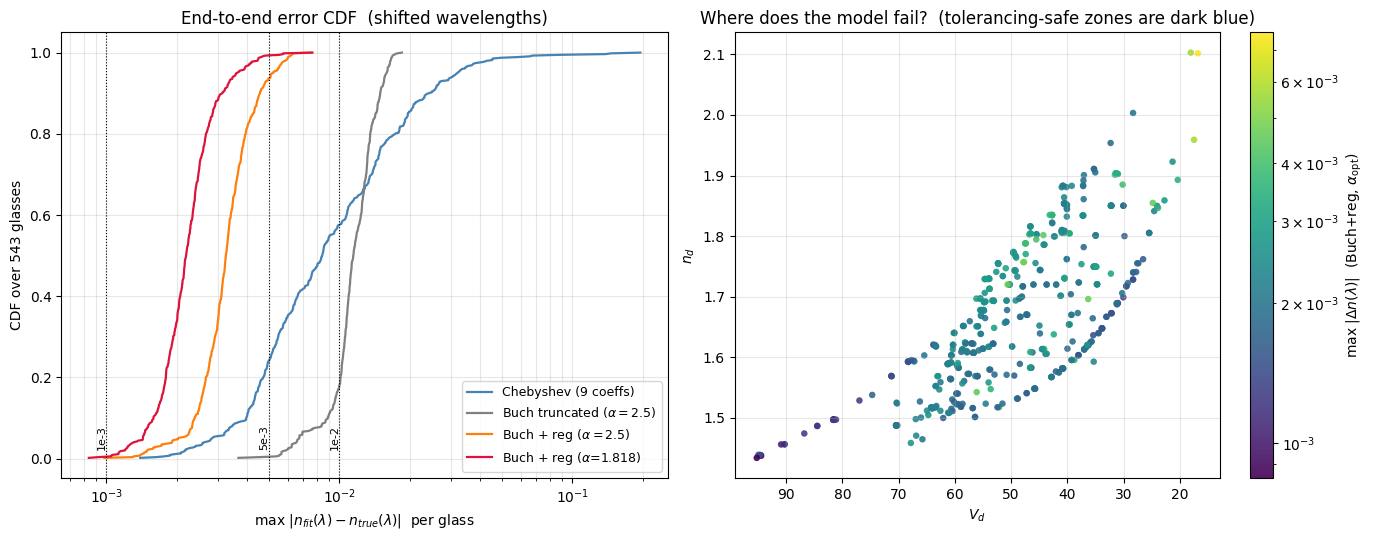

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) CDFs
ax = axes[0]
methods = [
    ("Chebyshev (9 coeffs)",                  all_cheby,      "steelblue"),
    (r"Buch truncated ($\alpha=2.5$)",         all_buch_trunc, "gray"),
    (r"Buch + reg ($\alpha=2.5$)",             all_buch_reg,   "tab:orange"),
    (fr"Buch + reg ($\alpha$={ALPHA_OPT:.3f})", all_buch_opt,   "crimson"),
]
for label, arr, color in methods:
    xs = np.sort(arr)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, lw=1.6, color=color, label=label)
for thr, txt in [(1e-3, "1e-3"), (5e-3, "5e-3"), (1e-2, "1e-2")]:
    ax.axvline(thr, ls=":", color="k", lw=0.8)
    ax.text(thr, 0.02, txt, fontsize=8, rotation=90, va="bottom", ha="right")
ax.set_xscale("log")
ax.set_xlabel(r"max $|n_{fit}(\lambda)-n_{true}(\lambda)|$  per glass")
ax.set_ylabel("CDF over 543 glasses")
ax.set_title("End-to-end error CDF  (shifted wavelengths)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9, loc="lower right")

# (b) Abbe diagram colored by Buch+reg(opt) error
ax = axes[1]
_nd = np.array([g["nd"] for g in glasses_filtered])
_vd = np.array([g["vd"] for g in glasses_filtered])
err = np.clip(all_buch_opt, 1e-5, None)
sc = ax.scatter(_vd, _nd, c=err, s=22, alpha=0.9, edgecolors="none",
                cmap="viridis", norm=LogNorm(vmin=err.min(), vmax=err.max()))
cb = plt.colorbar(sc, ax=ax)
cb.set_label(r"max $|\Delta n(\lambda)|$  (Buch+reg, $\alpha_\mathrm{opt}$)")
ax.set_xlabel(r"$V_d$")
ax.set_ylabel(r"$n_d$")
ax.invert_xaxis()
ax.set_title(r"Where does the model fail?  (tolerancing-safe zones are dark blue)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
# Part 8: Inspect Worst-Case Glasses

In [21]:
# ── Show detailed results for the worst glasses ──
print("=== Top 5 worst glasses for each method (shifted wavelengths) ===")

names = [g["name"] for g in glasses_filtered]

for method_name, errs in [
    ("Chebyshev", all_cheby),
    ("Buchdahl truncated", all_buch_trunc),
    ("Buchdahl + reg a=2.5", all_buch_reg),
    (f"Buchdahl + reg a={ALPHA_OPT:.3f}", all_buch_opt),
]:
    print(f"\n--- {method_name} (worst 5) ---")
    idx_sorted = np.argsort(errs)[::-1][:5]
    for i in idx_sorted:
        g = glasses_filtered[i]
        print(f"  {names[i]:<20} nd={g['nd']:.4f} Vd={g['vd']:.2f} dPgF={g['dPgF']:.4f}  "
              f"err={errs[i]:.6f}")

=== Top 5 worst glasses for each method (shifted wavelengths) ===

--- Chebyshev (worst 5) ---
  L-BBH1               nd=2.1019 Vd=16.79 dPgF=0.0564  err=0.195468
  L-BBH2               nd=2.1030 Vd=18.05 dPgF=0.0428  err=0.146457
  S-NPH3               nd=1.9591 Vd=17.47 dPgF=0.0455  err=0.138594
  S-NPH4               nd=1.8929 Vd=20.36 dPgF=0.0299  err=0.087864
  S-NPH5               nd=1.8590 Vd=22.73 dPgF=0.0228  err=0.067301

--- Buchdahl truncated (worst 5) ---
  S-NPH3               nd=1.9591 Vd=17.47 dPgF=0.0455  err=0.018538
  N-KZFS2              nd=1.5584 Vd=54.01 dPgF=-0.0111  err=0.017689
  H-LAK4L              nd=1.6400 Vd=60.20 dPgF=-0.0054  err=0.017380
  S-BSM81              nd=1.6400 Vd=60.08 dPgF=-0.0057  err=0.017127
  N-LAK8               nd=1.7130 Vd=53.83 dPgF=-0.0083  err=0.016899

--- Buchdahl + reg a=2.5 (worst 5) ---
  H-ZLAF76             nd=1.8501 Vd=30.06 dPgF=0.0068  err=0.007587
  S-NBH56              nd=1.8548 Vd=24.80 dPgF=0.0102  err=0.006400
  S-LAM

---
# Part 9: Save Regression Matrices

In [22]:
np.save("../data/regression_buchdahl_nu34_20dim.npy", A_buch)
np.save("../data/regression_buchdahl_nu34_10dim.npy", A_buch_simple)
np.save("../data/regression_buchdahl_nu34_20dim_opt.npy", A_buch_opt)

print("Saved:")
print(f"  regression_buchdahl_nu34_20dim.npy      shape={A_buch.shape}        (alpha=2.5)")
print(f"  regression_buchdahl_nu34_10dim.npy      shape={A_buch_simple.shape}        (alpha=2.5)")
print(f"  regression_buchdahl_nu34_20dim_opt.npy  shape={A_buch_opt.shape}        (alpha={ALPHA_OPT:.3f})")
print(f"\nOptimized alpha = {ALPHA_OPT:.3f}")

Saved:
  regression_buchdahl_nu34_20dim.npy      shape=(20, 2)        (alpha=2.5)
  regression_buchdahl_nu34_10dim.npy      shape=(10, 2)        (alpha=2.5)
  regression_buchdahl_nu34_20dim_opt.npy  shape=(20, 2)        (alpha=1.818)

Optimized alpha = 1.818


---
# Part 10: Runtime Example

Show the complete runtime pipeline for a single model glass.

In [23]:
# ── Runtime pipeline: both alpha=2.5 and optimized alpha ──

def predict_index_buchdahl(nd, vd, dPgF, lam, A_reg, alpha=2.5,
                           omega_g=OMEGA_g, omega_F=OMEGA_F, omega_C=OMEGA_C):
    """
    Complete runtime prediction of n(lambda) from model glass parameters.
    """
    # Step 1: analytical nu1, nu2
    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC
    M = np.array([
        [omega_F - omega_C, omega_F**2 - omega_C**2],
        [omega_g - omega_F, omega_g**2 - omega_F**2],
    ])
    nu12 = np.linalg.solve(M, np.array([dn_FC, dn_gF]))

    # Step 2: regressed nu3, nu4
    phi = feature_vec(nd, vd, dPgF)
    nu34 = phi @ A_reg

    # Step 3: evaluate
    omega = buchdahl_omega_alpha(lam, alpha)
    nu_all = np.array([nu12[0], nu12[1], nu34[0], nu34[1]])
    return buchdahl_eval(nd, nu_all, omega)


# ── Compare both versions on first glass ──
g_test = glasses_filtered[0]
lam_test = np.linspace(0.365, 2.3, 100)
n_true = get_indices(g_test, lam_test)

print(f"Test glass: {g_test['name']} ({g_test['catalog']})")
print(f"  nd = {g_test['nd']}, Vd = {g_test['vd']}, dPgF = {g_test['dPgF']}\n")

# alpha=2.5
n_pred_25 = predict_index_buchdahl(
    g_test["nd"], g_test["vd"], g_test["dPgF"], lam_test,
    A_buch, alpha=2.5, omega_g=OMEGA_g, omega_F=OMEGA_F, omega_C=OMEGA_C)

# alpha=optimized
n_pred_opt = predict_index_buchdahl(
    g_test["nd"], g_test["vd"], g_test["dPgF"], lam_test,
    A_buch_opt, alpha=ALPHA_OPT, omega_g=OMEGA_g_opt, omega_F=OMEGA_F_opt, omega_C=OMEGA_C_opt)

err_25  = np.abs(n_true - n_pred_25)
err_opt = np.abs(n_true - n_pred_opt)

print(f"  {'':>12} {'alpha=2.5':>12} {'alpha=' + f'{ALPHA_OPT:.3f}':>12}")
print(f"  {'Max error':>12} {err_25.max():>12.2e} {err_opt.max():>12.2e}")
print(f"  {'Mean error':>12} {err_25.mean():>12.2e} {err_opt.mean():>12.2e}")

print(f"\n  {'lambda (um)':<12} {'n_true':<12} {'n_a25':<12} {'err_a25':<10} {'n_opt':<12} {'err_opt':<10}")
print("  " + "-" * 68)
for i in range(0, 100, 10):
    print(f"  {lam_test[i]:<12.4f} {n_true[i]:<12.6f} "
          f"{n_pred_25[i]:<12.6f} {err_25[i]:<10.2e} "
          f"{n_pred_opt[i]:<12.6f} {err_opt[i]:<10.2e}")

Test glass: D-FK61-25 (cdgm)
  nd = 1.496530004925833, Vd = 81.53177218031001, dPgF = 0.03224491934129259

                  alpha=2.5  alpha=1.818
     Max error     1.47e-03     1.22e-03
    Mean error     7.77e-04     5.91e-04

  lambda (um)  n_true       n_a25        err_a25    n_opt        err_opt   
  --------------------------------------------------------------------
  0.3650       1.511316     1.510994     3.22e-04   1.511085     2.31e-04  
  0.5605       1.497445     1.497447     2.68e-06   1.497446     1.80e-06  
  0.7559       1.492748     1.492565     1.83e-04   1.492697     5.14e-05  
  0.9514       1.490299     1.489577     7.22e-04   1.489931     3.69e-04  
  1.1468       1.488603     1.487398     1.21e-03   1.487822     7.81e-04  
  1.3423       1.487177     1.485725     1.45e-03   1.486079     1.10e-03  
  1.5377       1.485823     1.484403     1.42e-03   1.484599     1.22e-03  
  1.7332       1.484449     1.483333     1.12e-03   1.483326     1.12e-03  
  1.9286      

---
# Summary

## Data Cleaning

`nd`, `Vd`, `dPgF` are **recomputed from Sellmeier coefficients** using the Schott normal line ($P_{g,F} = 0.6438 - 0.001682\,V_d$). This is necessary because different catalogs use different normal line baselines:

| Catalog | Implicit $A$ | Implicit $B$ | vs Schott |
|---------|:---:|:---:|:---|
| Schott | 0.6438 | $-1.682\times10^{-3}$ | reference |
| CDGM | 0.6457 | $-1.703\times10^{-3}$ | systematic offset ~$9\times10^{-4}$ |
| Ohara | 0.6415 | $-1.618\times10^{-3}$ | systematic offset ~$6\times10^{-4}$ |

Data errors detected and removed: L-BAL43 (stored dPgF=0.5415, recomputed $\approx -0.002$).

## Pipeline Comparison

| | Original (Chebyshev) | Buchdahl |
|---|---|---|
| Intermediate representation | Chebyshev 8th order (9 coeffs) | Buchdahl 4th order (4 coeffs) |
| Physical meaning of coeffs | None | $\nu_1$ = primary dispersion, $\nu_2$ = secondary |
| Coefficients from analytics | 0 / 9 | **2 / 4** ($\nu_1, \nu_2$) |
| Coefficients from regression | **9** | **2** ($\nu_3, \nu_4$) |
| Feature dimension | 20 | 10 or 20 |
| Regression target dimension | 9 | **2** |

## End-to-End Error (shifted wavelengths, 543 glasses)

| Method | Max Error | Mean Error | Glasses < 5e-3 |
|--------|:---------:|:----------:|:--------------:|
| Chebyshev (20-dim → 9 coeffs) | 0.195 | 0.0125 | 131 / 543 |
| Buchdahl truncated (only $\nu_1, \nu_2$) | 0.019 | 0.0117 | 2 / 543 |
| Buchdahl + reg $\alpha=2.5$ | **0.0076** | 0.0034 | 508 / 543 |
| Buchdahl + reg $\alpha=1.818$ | **0.0077** | **0.0023** | **539 / 543** |

## Key Insight

The Buchdahl model exploits the **physical structure** of the problem: the three input parameters
$(n_d, V_d, \Delta P_{g,F})$ directly encode primary and secondary dispersion, which map
analytically to Buchdahl's first two coefficients. Only the small higher-order residuals
need statistical regression, dramatically reducing the regression burden.

Ensuring a **unified normal line baseline** across all catalogs is critical — without it, the analytical $\nu_2$ is polluted by catalog-dependent offsets in stored `dPgF` values.